# Final Training for Attention-Based Bi-LSTM with Data Augmentation and Feature Engineering

This notebook performs final model training on the complete training set after cross-validation optimization. The trained model is evaluated on the held-out test set at multiple granularities (sequence, file, and person levels) with comprehensive attention weight analysis to understand the model's decision-making process.

# Configuration and Setup

Setting up the environment for reproducible final model training:
- **Seed Configuration**: Fixed random seed (42) across all libraries (Python, NumPy, TensorFlow)
- **Deterministic Operations**: TensorFlow configured for deterministic GPU operations
- **Channel Selection**: Five key handwriting dynamics features (Fingergrip, Axial Pressure, Tilt X/Y/Z)
- **Environment Variables**: PYTHONHASHSEED and TF_DETERMINISTIC_OPS set for consistency

In [13]:
# =====================================
# CONFIGURATION AND SETUP
# =====================================

import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from sklearn.utils import class_weight
import pickle
from scipy.stats import entropy

# SET SEEDS FOR REPRODUCIBILITY
seed = 42

# Must be set before importing TensorFlow
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import tensorflow as tf

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Set pandas display options
pd.set_option('display.max_columns', None)

# Updated channel names (excluding Microphone)
channel_names = [
    "Fingergrip", "Axial_Pressure",
    "Tilt_X", "Tilt_Y", "Tilt_Z"
]

# Data Loading

Loading preprocessed training and testing datasets with applied augmentation and feature engineering:
- **Training Data**: Complete augmented training set for final model training
- **Testing Data**: Held-out test set never seen during training or cross-validation
- **Data Format**: Pickle files containing windowed sequences with labels and metadata
- **Features Included**: Statistical features, mass calculations, delta values, and temporal patterns

In [14]:
# =====================================
# LOAD THE CLEAN, SPLIT DATA
# =====================================

df_train = pd.read_pickle('C:/Users/Tristan/Documents/Pipelines/With Aug and FE/df_train.pkl')
df_test = pd.read_pickle('C:/Users/Tristan/Documents/Pipelines/With Aug and FE/df_test.pkl')

print("Clean data loaded.")
print(f"Training samples: {len(df_train)}")
print(f"Testing samples: {len(df_test)}")

Clean data loaded.
Training samples: 32637
Testing samples: 2577


# Model Dependencies

Importing essential libraries for deep learning model construction and evaluation:
- **TensorFlow/Keras**: Neural network architecture (Bi-LSTM, Attention layers)
- **Optimization**: Adam optimizer with learning rate scheduling and regularization
- **Metrics**: Classification reports, confusion matrices, ROC/PR curves, AUC scores
- **Data Splitting**: Train-test split utilities for final evaluation

In [15]:
# =====================================
# IMPORTS FOR MODELING
# =====================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, auc
import seaborn as sns
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.model_selection import train_test_split


# Sequence Generation and Normalization

Creating overlapping temporal sequences from windowed data for LSTM processing:
- **Sequence Length**: 20 consecutive windows per sequence
- **Step Size**: 10 windows overlap to capture temporal continuity
- **Feature Selection**: Excluding metadata columns (label, file_name, Person_ID, demographics)
- **Standardization**: StandardScaler fitted on training data and applied to both train and test sets
- **Output Shape**: (n_sequences, 20, n_features) for Bi-LSTM input

In [16]:
# =====================================
# CREATE SEQUENCES OF WINDOWS
# =====================================

def create_sequences(df, feature_cols, sequence_length, step_size):
    sequences = []
    labels = []
    file_names = []
    person_ids = []
    grouped = df.groupby('file_name')
    print(f"Creating sequences of length {sequence_length} with step {step_size}...")
    for file_name, group in tqdm(grouped):
        features = group[feature_cols].values
        if len(features) < sequence_length:
            continue
        label = group['label'].iloc[0]
        person_id = group['Person_ID_Number'].iloc[0]
        for i in range(0, len(features) - sequence_length + 1, step_size):
            sequence = features[i : i + sequence_length]
            sequences.append(sequence)
            labels.append(label)
            file_names.append(file_name)
            person_ids.append(person_id)
    return np.array(sequences), np.array(labels), np.array(file_names), np.array(person_ids)

# Define non-feature columns in delta DataFrame
base_non_feature_cols = ['label', 'file_name', 'start_index', 'end_index', 'Person_ID_Number',
                        'Age', 'Gender', 'Writing_Hand', 'augmented', 'original_duration', 'target_duration']

# Determine feature columns: include stats, mass, delta_... etc.
feature_cols = [col for col in df_train.columns if col not in base_non_feature_cols]
feature_cols = [col for col in feature_cols if np.issubdtype(df_train[col].dtype, np.number)]

SEQUENCE_LENGTH = 20
STEP_SIZE = 10

X_train_seq, y_train_seq, sequence_file_names_train, sequence_person_ids_train = create_sequences(df_train, feature_cols, SEQUENCE_LENGTH, STEP_SIZE)
X_test_seq, y_test_seq, sequence_file_names_test, sequence_person_ids_test = create_sequences(df_test, feature_cols, SEQUENCE_LENGTH, STEP_SIZE)

print("\n--- Data Shapes After Sequencing ---")
print(f"X_train sequences shape: {X_train_seq.shape}")
print(f"y_train sequences shape: {y_train_seq.shape}")
print(f"X_test sequences shape: {X_test_seq.shape}")

n_features = X_train_seq.shape[2]
X_train_reshaped_for_scaling = X_train_seq.reshape(-1, n_features)
X_test_reshaped_for_scaling = X_test_seq.reshape(-1, n_features)

scaler = StandardScaler()
X_train_scaled_flat = scaler.fit_transform(X_train_reshaped_for_scaling)
X_test_scaled_flat = scaler.transform(X_test_reshaped_for_scaling)

X_train_final = X_train_scaled_flat.reshape(X_train_seq.shape)
X_test_final = X_test_scaled_flat.reshape(X_test_seq.shape)

print("\n--- Final Data Shapes for LSTM Model ---")
print(f"Final X_train shape: {X_train_final.shape}")
print(f"Final X_test shape: {X_test_final.shape}")

Creating sequences of length 20 with step 10...


100%|██████████| 445/445 [00:01<00:00, 267.42it/s]


Creating sequences of length 20 with step 10...


100%|██████████| 80/80 [00:00<00:00, 493.71it/s]


--- Data Shapes After Sequencing ---
X_train sequences shape: (2623, 20, 150)
y_train sequences shape: (2623,)
X_test sequences shape: (139, 20, 150)



--- Final Data Shapes for LSTM Model ---
Final X_train shape: (2623, 20, 150)
Final X_test shape: (139, 20, 150)


# Model Architecture: Attention-Based Bi-LSTM

Building a deep learning model that combines bidirectional temporal processing with attention mechanisms:
- **Bi-LSTM Layer**: 64 units capturing forward and backward temporal dependencies
- **Attention Mechanism**: Custom layer computing weighted importance of time steps
- **Regularization**: L2 regularization (0.0001) and Dropout (0.4) to prevent overfitting
- **Dense Layer**: 16-unit fully connected layer with ReLU activation
- **Output**: Sigmoid activation for binary classification (Parkinson's vs. Control)
- **Optimization**: Adam optimizer with binary cross-entropy loss

In [17]:
# =====================================
# MODEL: BiLSTM + Attention
# =====================================

class Attention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(1,), initializer="zeros")
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

def create_bilstm_model(input_shape):
    inputs = Input(shape=input_shape)

    x = Bidirectional(
        LSTM(64, return_sequences=True, kernel_regularizer=l2(0.0001))
    )(inputs)
    x = Dropout(0.4)(x)
    x = Attention()(x)
    x = Dense(16, activation='relu', kernel_regularizer=l2(0.0001))(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.0001),
        metrics=['accuracy']
    )
    return model

# Final Model Training

Training the final model on the complete training dataset:
- **Training Epochs**: 13 epochs (determined from cross-validation early stopping patterns)
- **Batch Size**: 64 samples per batch
- **No Validation Split**: Using all training data to maximize model learning
- **Learning Curves**: Monitoring training accuracy and loss progression
- **Purpose**: Create production-ready model for deployment and final test evaluation


Training final model...
Epoch 1/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6332 - loss: 0.6715
Epoch 2/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7362 - loss: 0.5923
Epoch 3/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7766 - loss: 0.5381
Epoch 4/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8029 - loss: 0.5059
Epoch 5/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8277 - loss: 0.4601
Epoch 6/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8551 - loss: 0.4285
Epoch 7/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8650 - loss: 0.3918
Epoch 8/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8875 - loss: 0.3700
Epoch 9/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8978 - loss: 0.3396
Epoch 10/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9104 - loss: 0.3139
Epoch 11/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9218 - loss: 0.2853
Epoch 12/13
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/s

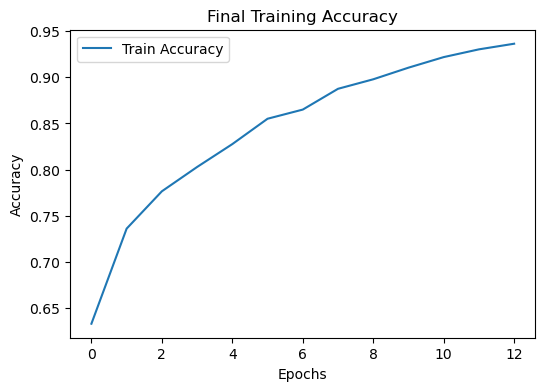

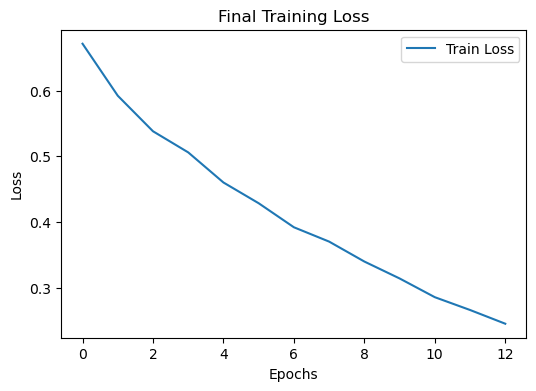

In [18]:
# =====================================
# FINAL TRAINING
# =====================================

final_model = create_bilstm_model(input_shape=(X_train_final.shape[1], X_train_final.shape[2]))

final_epochs = 13

print(f"\nTraining final model...")
history_final = final_model.fit(
    X_train_final, y_train_seq,
    epochs=final_epochs,
    batch_size=64,
    verbose=1
)

# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.title('Final Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(history_final.history['loss'], label='Train Loss')
plt.title('Final Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Sequence-Level Evaluation

Evaluating model performance at the individual sequence level (finest granularity):
- **Predictions**: Binary classification for each 20-window sequence
- **Metrics**: Accuracy, precision, recall, F1-score for both classes
- **Confusion Matrix**: True positive/negative vs predicted classifications
- **ROC Curve**: True positive rate vs false positive rate with AUC score
- **Precision-Recall Curve**: Precision vs recall trade-off with average precision
- **Use Case**: Understanding model performance on individual temporal windows

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/stepWARNING:tensorflow:6 out of the last 13 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001B49F08FCE0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step

Sequence-level Accuracy: 0.8777


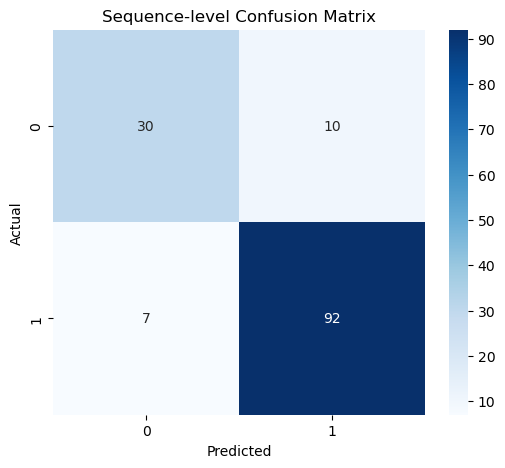


Sequence-level Classification Report:
              precision    recall  f1-score   support

           0     0.8108    0.7500    0.7792        40
           1     0.9020    0.9293    0.9154        99

    accuracy                         0.8777       139
   macro avg     0.8564    0.8396    0.8473       139
weighted avg     0.8757    0.8777    0.8762       139



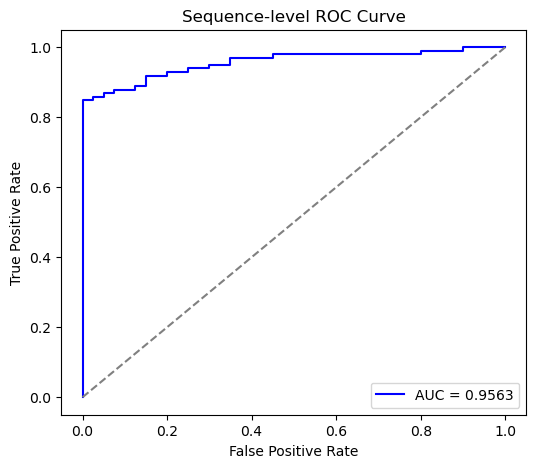

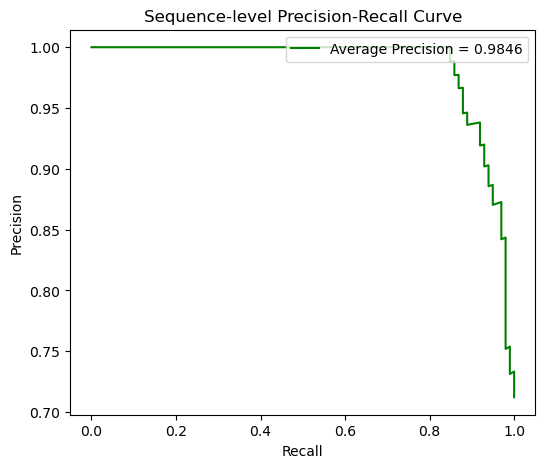

In [19]:
# =====================================
# EVALUATE (SEQUENCE-LEVEL)
# =====================================

# Predict
y_test_pred_prob = final_model.predict(X_test_final)
y_test_pred = (y_test_pred_prob > 0.5).astype(int).flatten()

# Accuracy 
overall_accuracy = accuracy_score(y_test_seq, y_test_pred)
print(f"\nSequence-level Accuracy: {overall_accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_seq, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sequence-level Confusion Matrix")
plt.show()

# Classification Report
print("\nSequence-level Classification Report:")
print(classification_report(y_test_seq, y_test_pred, digits=4))

# ROC Curve AND AUC
fpr, tpr, thresholds = roc_curve(y_test_seq, y_test_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Sequence-level ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curves
precision, recall, thresholds_pr = precision_recall_curve(y_test_seq, y_test_pred_prob)
avg_precision = average_precision_score(y_test_seq, y_test_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green', label=f"Average Precision = {avg_precision:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Sequence-level Precision-Recall Curve")
plt.legend(loc="upper right")
plt.show()

# File-Level Evaluation

Aggregating predictions to the file level (one handwriting sample per person):
- **Aggregation Method**: Averaging prediction probabilities across all sequences from the same file
- **Threshold**: 0.5 probability cutoff for binary classification
- **Clinical Relevance**: Each file represents one complete handwriting task
- **Metrics**: Same comprehensive metrics as sequence-level (accuracy, AUC, precision, recall, F1)
- **Use Case**: More stable predictions by combining multiple temporal observations


File-level Accuracy: 0.7759


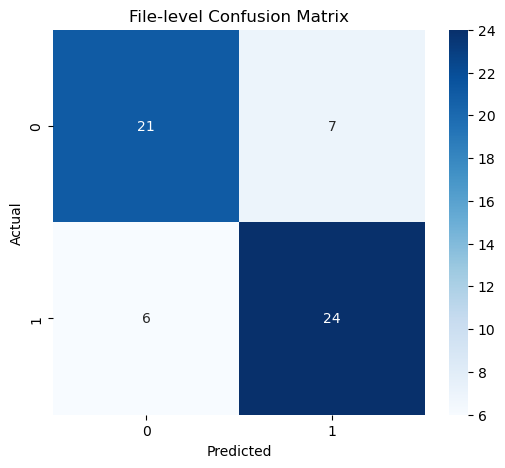


File-level Classification Report:
              precision    recall  f1-score   support

           0     0.7778    0.7500    0.7636        28
           1     0.7742    0.8000    0.7869        30

    accuracy                         0.7759        58
   macro avg     0.7760    0.7750    0.7753        58
weighted avg     0.7759    0.7759    0.7757        58



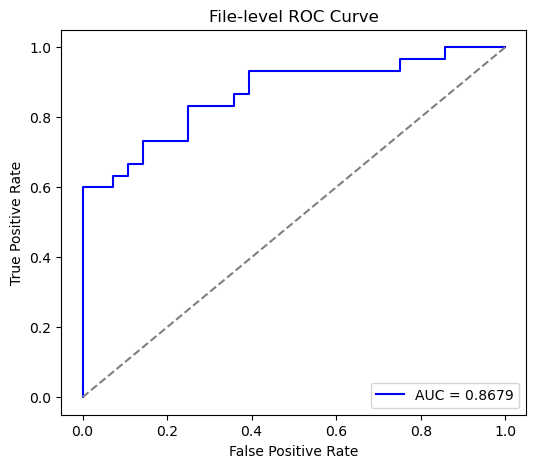

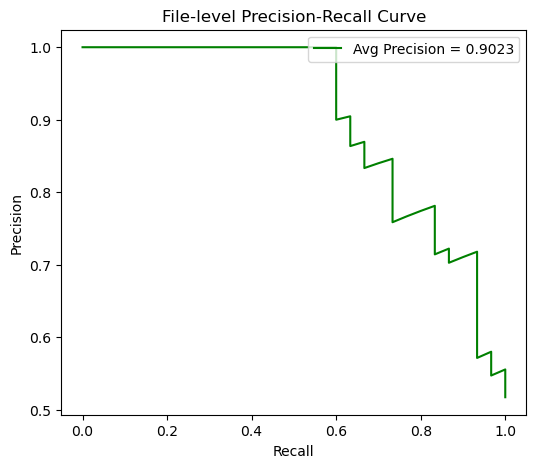

In [20]:
# =====================================
# EVALUATE (FILE-LEVEL)
# =====================================

# Aggregate per file
df_pred = pd.DataFrame({
    "file_name": sequence_file_names_test,
    "true_label": y_test_seq,
    "pred_label": y_test_pred,
    "pred_prob": y_test_pred_prob.flatten()
})

# Average predicted probability for ROC/PR curves
file_level_prob = df_pred.groupby("file_name")["pred_prob"].mean()
file_level_pred = (file_level_prob >= 0.5).astype(int)

# Get true label
file_level_true = df_pred.groupby("file_name")["true_label"].first()

# Accuracy
file_accuracy = accuracy_score(file_level_true, file_level_pred)
print(f"\nFile-level Accuracy: {file_accuracy:.4f}")

# Confusion Matrix
cm_file = confusion_matrix(file_level_true, file_level_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_file, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("File-level Confusion Matrix")
plt.show()

# Classification Report
print("\nFile-level Classification Report:")
print(classification_report(file_level_true, file_level_pred, digits=4))

# ROC Curve & AUC
fpr_file, tpr_file, _ = roc_curve(file_level_true, file_level_prob)
roc_auc_file = auc(fpr_file, tpr_file)

plt.figure(figsize=(6,5))
plt.plot(fpr_file, tpr_file, color='blue', label=f"AUC = {roc_auc_file:.4f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("File-level ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision_file, recall_file, _ = precision_recall_curve(file_level_true, file_level_prob)
avg_precision_file = average_precision_score(file_level_true, file_level_prob)

plt.figure(figsize=(6,5))
plt.plot(recall_file, precision_file, color='green', label=f"Avg Precision = {avg_precision_file:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("File-level Precision-Recall Curve")
plt.legend(loc="upper right")
plt.show()

# Person-Level Evaluation

Aggregating predictions to the person level (highest clinical relevance):
- **Aggregation Method**: Averaging prediction probabilities across all sequences from the same person
- **Threshold**: 0.5 probability cutoff for final diagnosis
- **Clinical Application**: Most relevant for real-world screening scenarios
- **Robustness**: Multiple observations per person reduce noise and outlier effects
- **Metrics**: Same comprehensive evaluation metrics
- **Use Case**: Final diagnostic decision for each individual patient/control


Person-level Accuracy: 0.8889


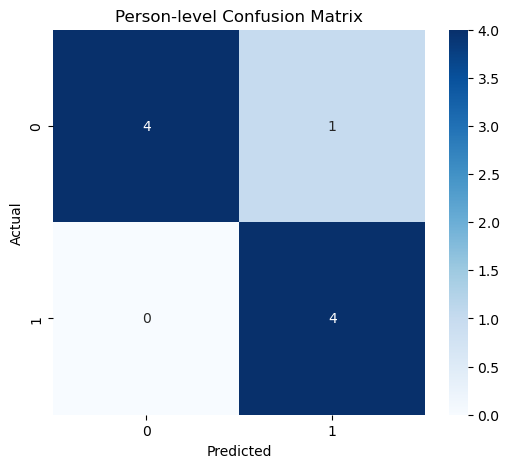


Person-level Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.8000    0.8889         5
           1     0.8000    1.0000    0.8889         4

    accuracy                         0.8889         9
   macro avg     0.9000    0.9000    0.8889         9
weighted avg     0.9111    0.8889    0.8889         9



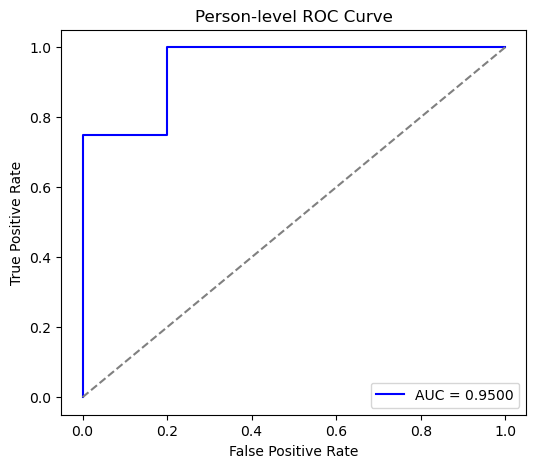

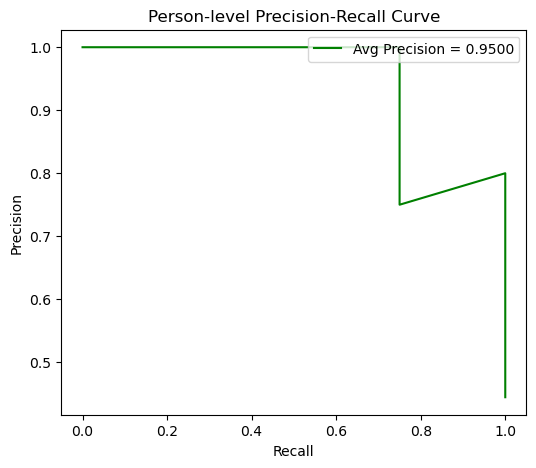

In [21]:
# =====================================
# EVALUATE (PERSON-LEVEL)
# =====================================

# Aggregate per person
df_pred_person = pd.DataFrame({
    "person_id": sequence_person_ids_test,
    "true_label": y_test_seq,   
    "pred_label": y_test_pred,
    "pred_prob": y_test_pred_prob.flatten()
})

# Average predicted probability for ROC/PR curves
person_level_prob = df_pred_person.groupby("person_id")["pred_prob"].mean()
person_level_pred = (person_level_prob >= 0.5).astype(int)

# Get true label
person_level_true = df_pred_person.groupby("person_id")["true_label"].first()

# Accuracy
person_accuracy = accuracy_score(person_level_true, person_level_pred)
print(f"\nPerson-level Accuracy: {person_accuracy:.4f}")

# Confusion Matrix
cm_person = confusion_matrix(person_level_true, person_level_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_person, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Person-level Confusion Matrix")
plt.show()

# Classification Report
print("\nPerson-level Classification Report:")
print(classification_report(person_level_true, person_level_pred, digits=4))

# ROC Curve & AUC
fpr_person, tpr_person, _ = roc_curve(person_level_true, person_level_prob)
roc_auc_person = auc(fpr_person, tpr_person)
plt.figure(figsize=(6,5))
plt.plot(fpr_person, tpr_person, color='blue', label=f"AUC = {roc_auc_person:.4f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Person-level ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision_person, recall_person, _ = precision_recall_curve(person_level_true, person_level_prob)
avg_precision_person = average_precision_score(person_level_true, person_level_prob)
plt.figure(figsize=(6,5))
plt.plot(recall_person, precision_person, color='green', label=f"Avg Precision = {avg_precision_person:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Person-level Precision-Recall Curve")
plt.legend(loc="upper right")
plt.show()

# Multi-Level Performance Comparison

Comprehensive comparison of model performance across all three evaluation granularities:
- **Sequence Level**: Individual predictions on 20-window sequences
- **File Level**: Aggregated predictions per handwriting sample
- **Person Level**: Aggregated predictions per participant
- **Comparison Metrics**: Accuracy, AUC, precision, recall, and F1-score for both classes
- **Expected Pattern**: Performance typically improves with aggregation due to noise reduction
- **Clinical Insight**: Person-level metrics most relevant for diagnostic utility

In [22]:
# =====================================
# COMPARISON TABLE
# =====================================

# Sequence-level metrics
seq_accuracy = overall_accuracy
seq_auc = roc_auc
seq_report = classification_report(y_test_seq, y_test_pred, output_dict=True)

seq_prec_0 = seq_report['0']['precision']
seq_rec_0 = seq_report['0']['recall']
seq_f1_0 = seq_report['0']['f1-score']
seq_prec_1 = seq_report['1']['precision']
seq_rec_1 = seq_report['1']['recall']
seq_f1_1 = seq_report['1']['f1-score']

# File-level metrics
file_acc = file_accuracy
file_auc = roc_auc_file
file_report = classification_report(file_level_true, file_level_pred, output_dict=True)

file_prec_0 = file_report['0']['precision']
file_rec_0 = file_report['0']['recall']
file_f1_0 = file_report['0']['f1-score']
file_prec_1 = file_report['1']['precision']
file_rec_1 = file_report['1']['recall']
file_f1_1 = file_report['1']['f1-score']

# Person-level metrics
person_acc = person_accuracy
person_auc = roc_auc_person
person_report = classification_report(person_level_true, person_level_pred, output_dict=True)

person_prec_0 = person_report['0']['precision']
person_rec_0 = person_report['0']['recall']
person_f1_0 = person_report['0']['f1-score']
person_prec_1 = person_report['1']['precision']
person_rec_1 = person_report['1']['recall']
person_f1_1 = person_report['1']['f1-score']


final_results_table = pd.DataFrame({
    "Metric": [
        "Accuracy", "AUC",
        "Precision (Class 0)", "Recall (Class 0)", "F1 (Class 0)",
        "Precision (Class 1)", "Recall (Class 1)", "F1 (Class 1)"
    ],
    "Sequence Level": [
        f"{seq_accuracy:.4f}", f"{seq_auc:.4f}",
        f"{seq_prec_0:.4f}", f"{seq_rec_0:.4f}", f"{seq_f1_0:.4f}",
        f"{seq_prec_1:.4f}", f"{seq_rec_1:.4f}", f"{seq_f1_1:.4f}"
    ],
    "File Level": [
        f"{file_acc:.4f}", f"{file_auc:.4f}",
        f"{file_prec_0:.4f}", f"{file_rec_0:.4f}", f"{file_f1_0:.4f}",
        f"{file_prec_1:.4f}", f"{file_rec_1:.4f}", f"{file_f1_1:.4f}"
    ],
    "Person Level": [
        f"{person_acc:.4f}", f"{person_auc:.4f}",
        f"{person_prec_0:.4f}", f"{person_rec_0:.4f}", f"{person_f1_0:.4f}",
        f"{person_prec_1:.4f}", f"{person_rec_1:.4f}", f"{person_f1_1:.4f}"
    ]
})

print("\nFinal Performance Comparison: Sequence vs File vs Person Level")
display(final_results_table)


Final Performance Comparison: Sequence vs File vs Person Level


,Metric,Sequence Level,File Level,Person Level
0,Accuracy,0.8777,0.7759,0.8889
1,AUC,0.9563,0.8679,0.9500
2,Precision (Class 0),0.8108,0.7778,1.0000
3,Recall (Class 0),0.7500,0.7500,0.8000
4,F1 (Class 0),0.7792,0.7636,0.8889
5,Precision (Class 1),0.9020,0.7742,0.8000
6,Recall (Class 1),0.9293,0.8000,1.0000
7,F1 (Class 1),0.9154,0.7869,0.8889


# Attention Weights Analysis - Final Model on Test Set

Extracting and analyzing attention weights from the final trained model to understand which temporal patterns drive predictions. This provides:
- **Model Interpretability**: Reveals which time steps the model focuses on for classification
- **Clinical Validation**: Identifies specific moments in writing behavior that distinguish patients from controls
- **Feature Importance**: Shows temporal patterns most indicative of Parkinson's motor impairment
- **Diagnostic Insight**: Helps clinicians understand the basis for automated predictions


ATTENTION WEIGHTS EXTRACTION FROM FINAL MODEL
✅ Found Attention layer: attention_1
✅ Attention extraction model built successfully

📊 Extracting attention weights for test set...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step

Attention weights shape: (139, 20)
Shape interpretation: (139 test sequences, 20 time steps)

✓ Attention Weight Normalization Verification:
  Min sum: 0.99999988
  Max sum: 1.00000024
  Mean sum: 1.00000000
  All samples sum to ~1.0: True

✓ Attention weights extracted successfully!

FOCUSED ATTENTION ANALYSIS: HEALTHY VS PATIENT (TEST SET)

📊 TOP 5 TIME STEPS WITH LARGEST ATTENTION DIFFERENCE:
1. Time Step 20: Healthy=0.0522, Patient=0.0407, Diff=-0.0114
2. Time Step 19: Healthy=0.0506, Patient=0.0413, Diff=-0.0092
3. Time Step 18: Healthy=0.0498, Patient=0.0429, Diff=-0.0069
4. Time Step 17: Healthy=0.0501, Patient=0.0437, Diff=-0.0064
5. Time Step 16: Healthy=0.0512, Patient=0.0448, Diff=-0.0064

📊 TOP 5 TIME STEPS MOST ATTENDED BY PATIENTS:
1. Time Step 20: Patient

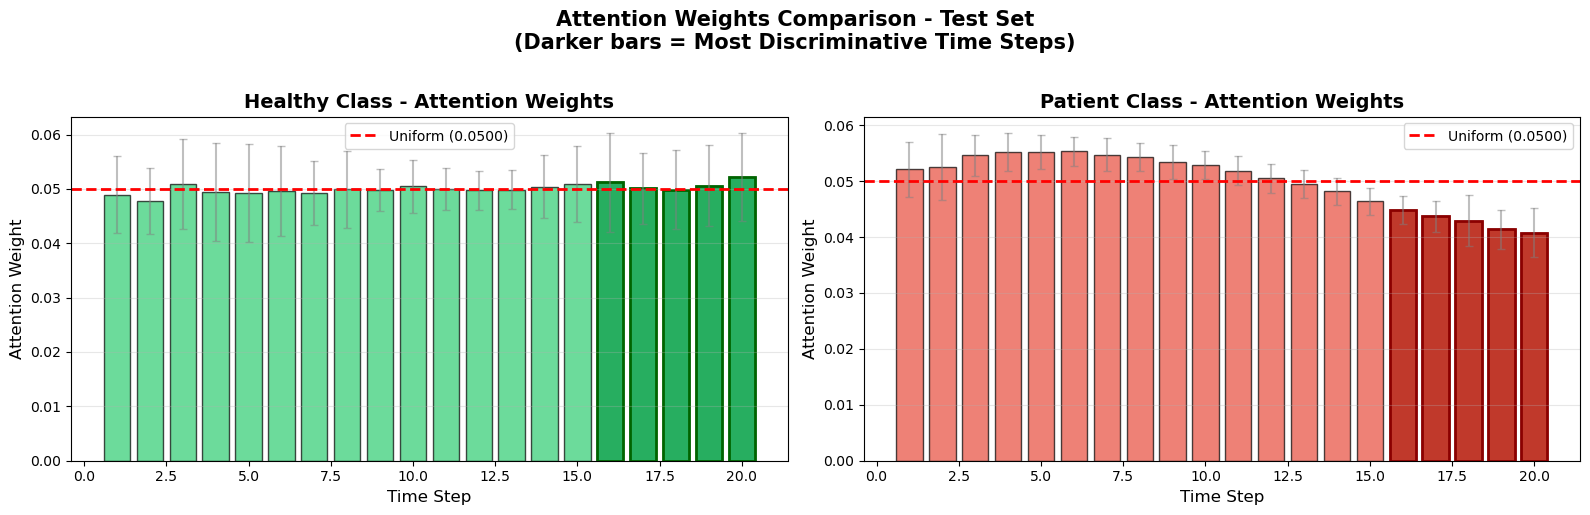

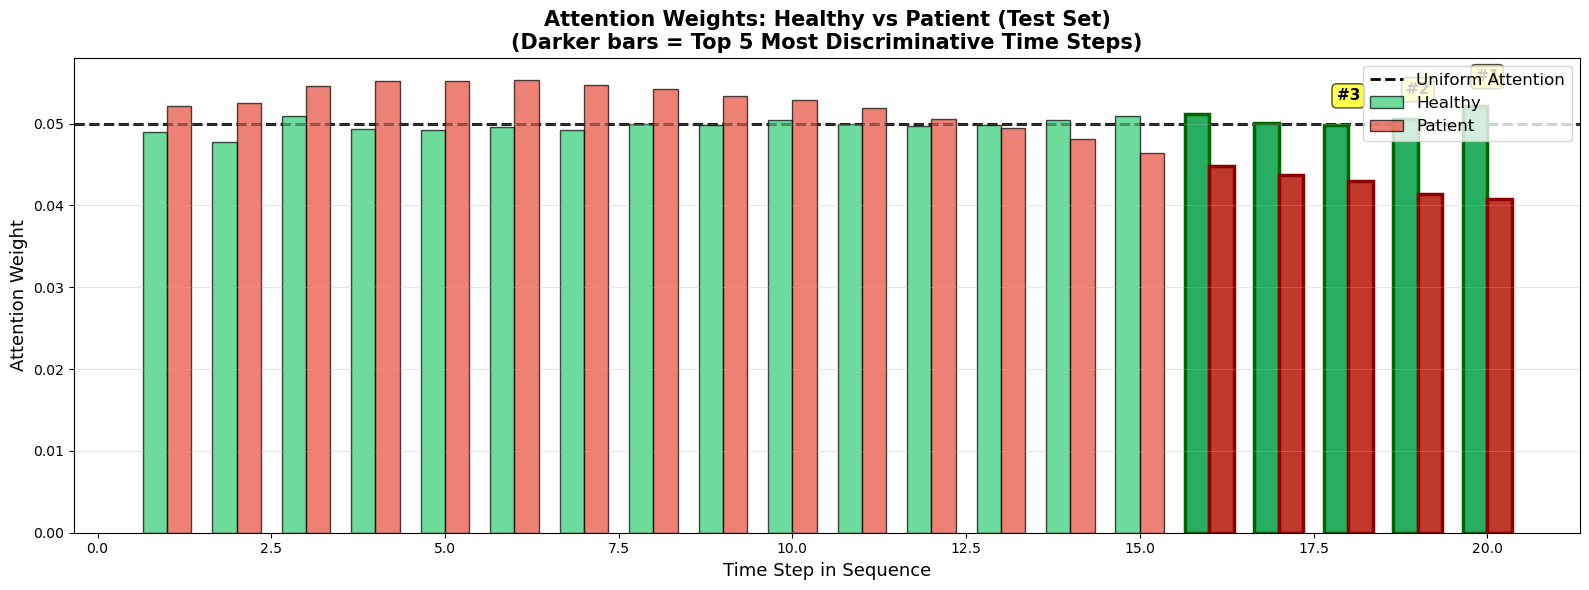

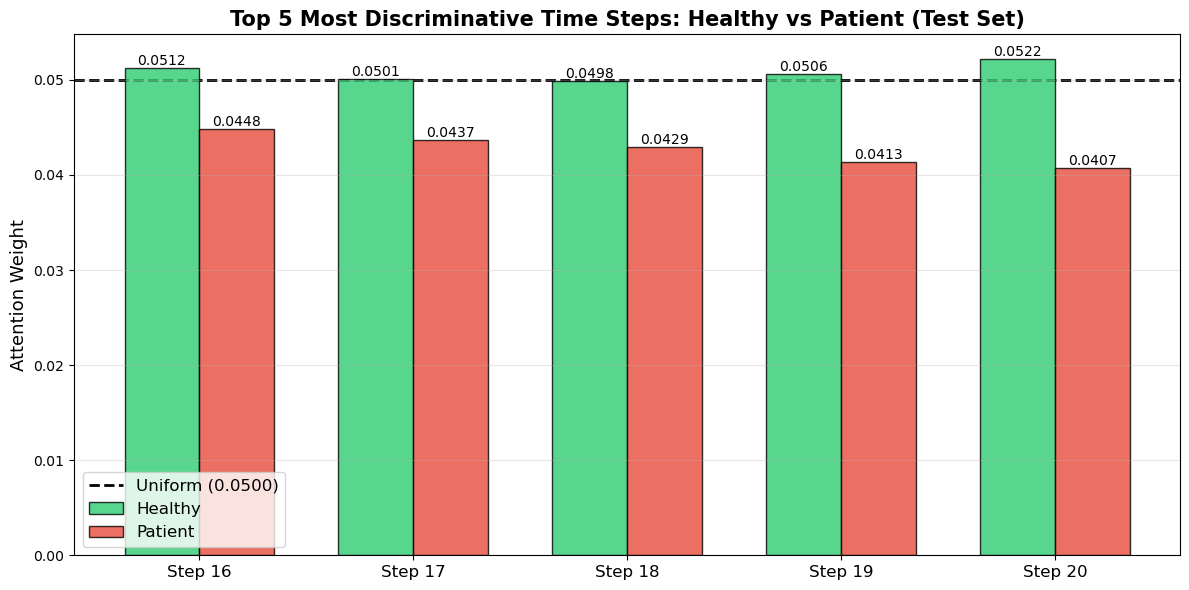


📊 Creating Heatmap Visualizations...


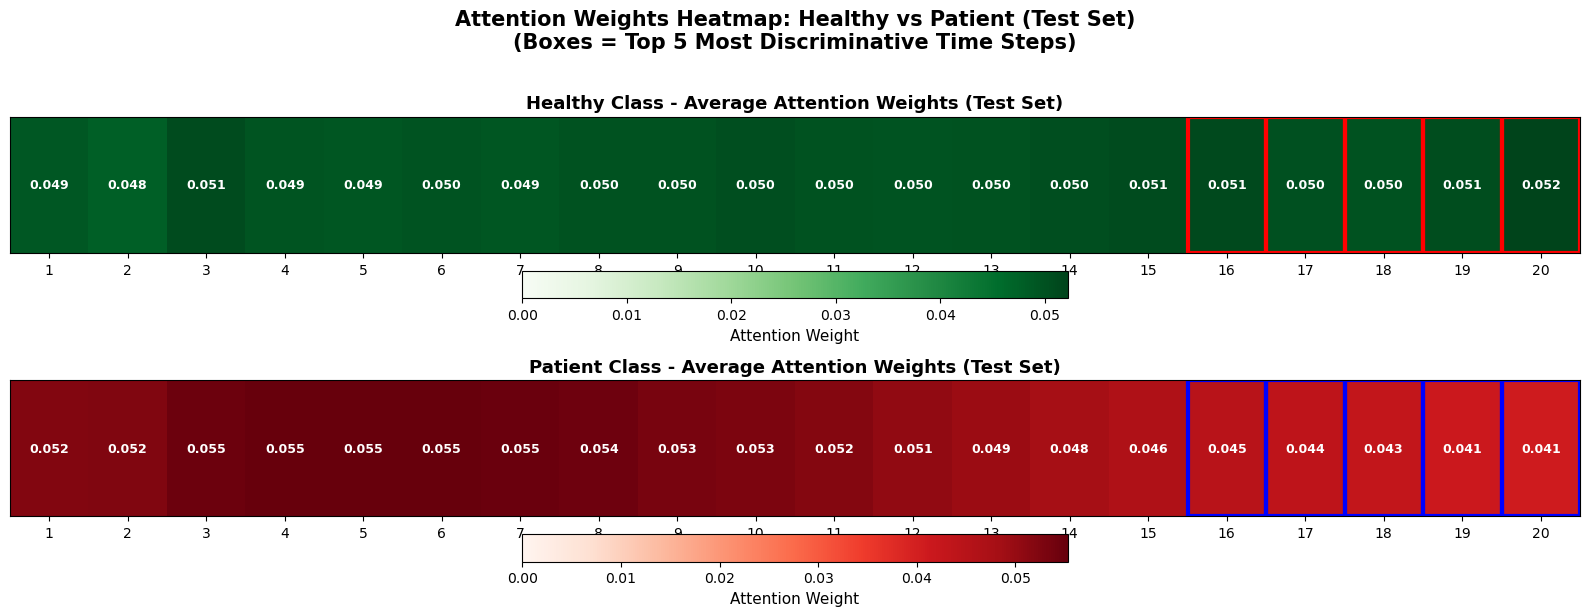

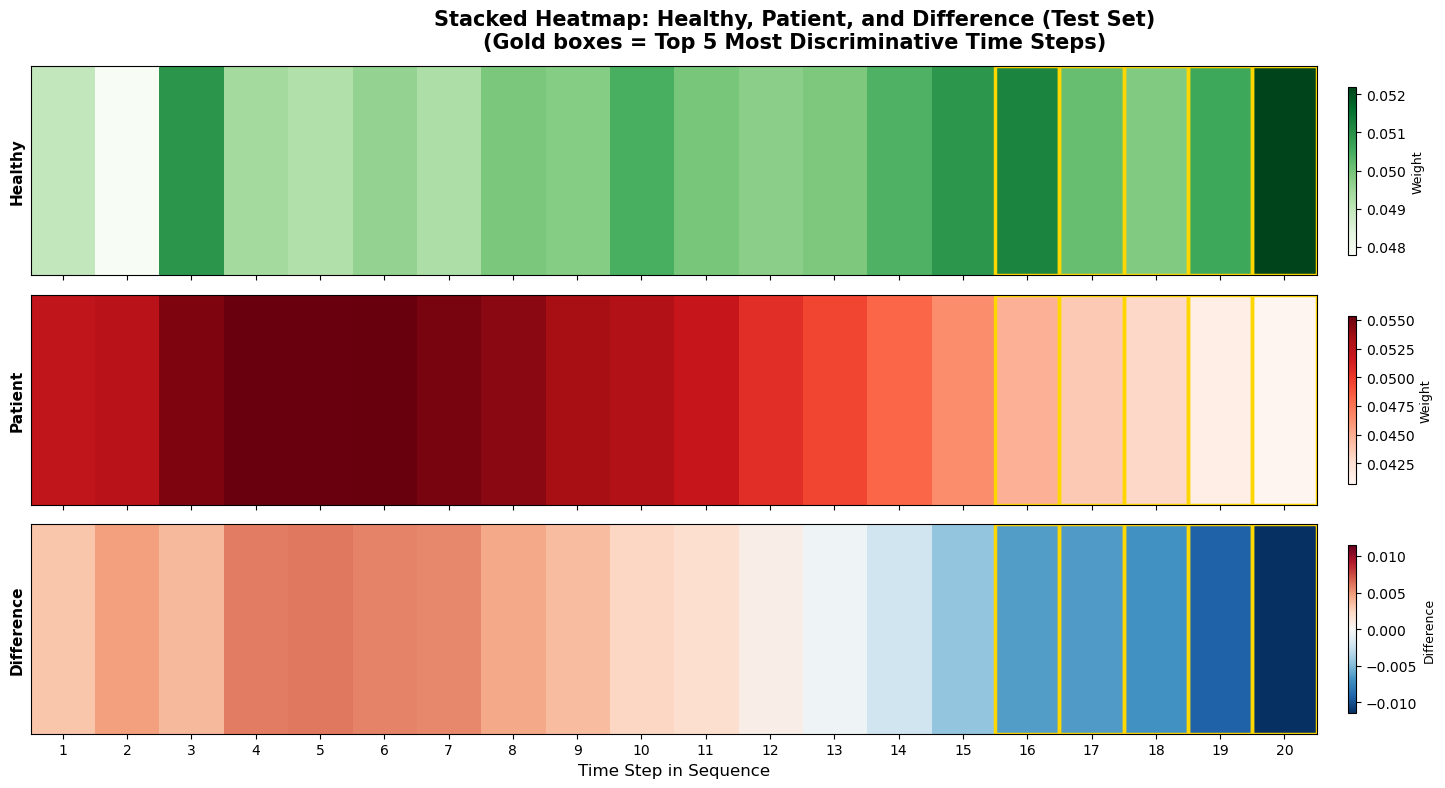

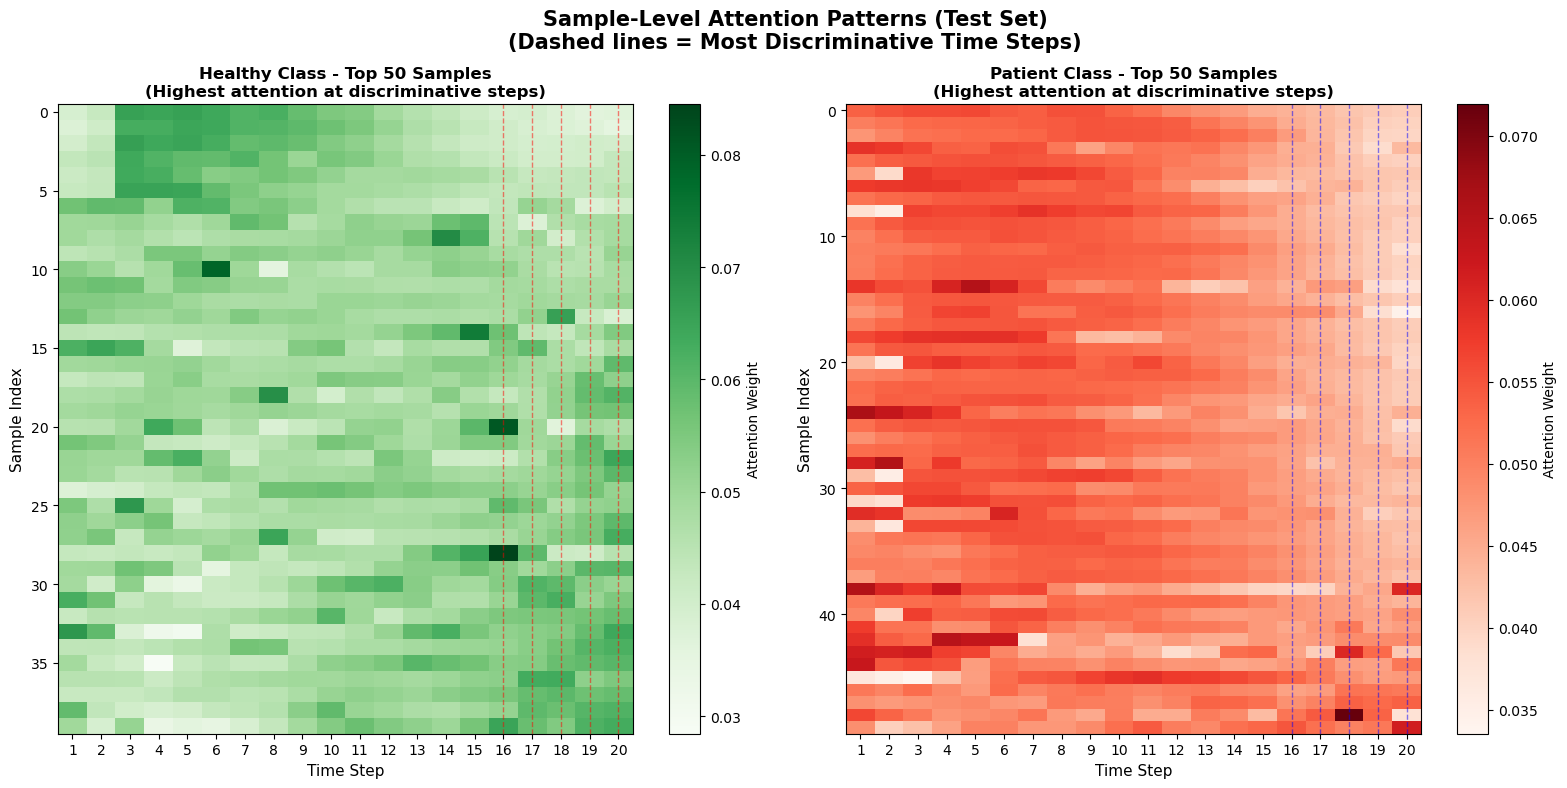


ATTENTION ANALYSIS SUMMARY (TEST SET)

📈 OVERALL STATISTICS:
  Healthy - Mean: 0.0500, Std: 0.0009
  Patient - Mean: 0.0500, Std: 0.0049
  Uniform Baseline: 0.0500

🎯 ATTENTION CONCENTRATION:
  Healthy max/uniform ratio: 1.04x
  Patient max/uniform ratio: 1.11x

📊 STATISTICAL SIGNIFICANCE (Top 5 Time Steps):
  Step 20: t=+10.682, p=0.0000 ***
  Step 19: t=+9.902, p=0.0000 ***
  Step 18: t=+6.688, p=0.0000 ***
  Step 17: t=+8.066, p=0.0000 ***
  Step 16: t=+6.363, p=0.0000 ***

ATTENTION ANALYSIS COMPLETE

✅ Attention weights analysis saved to: final_model_attention_weights_analysis.pkl


In [23]:
# =====================================
# BUILD ATTENTION EXTRACTION MODEL
# =====================================

print("\n" + "="*80)
print("ATTENTION WEIGHTS EXTRACTION FROM FINAL MODEL")
print("="*80)

# Create a modified Attention layer that returns both output and weights
class AttentionWithWeights(tf.keras.layers.Layer):
    """Modified Attention layer that returns both output and attention weights"""
    def __init__(self, **kwargs):
        super(AttentionWithWeights, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(1,), initializer="zeros")
        super(AttentionWithWeights, self).build(input_shape)
    
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1), a

# Find the trained attention layer
trained_attention_layer = None
for layer in final_model.layers:
    if isinstance(layer, Attention):
        trained_attention_layer = layer
        break

if trained_attention_layer is None:
    print("❌ ERROR: No Attention layer found in model!")
else:
    print(f"✅ Found Attention layer: {trained_attention_layer.name}")
    
    # Build attention extraction model
    inputs = Input(shape=(X_test_final.shape[1], X_test_final.shape[2]))
    
    # Get the BiLSTM layer (should be layer index 1)
    bilstm_layer = final_model.layers[1]
    x = bilstm_layer(inputs)
    
    # Get the Dropout layer (should be layer index 2)
    dropout_layer = final_model.layers[2]
    x = dropout_layer(x, training=False)  # Set training=False for inference
    
    # Create new attention layer that returns weights
    attention_with_weights = AttentionWithWeights()
    attention_output, attention_weights = attention_with_weights(x)
    
    # Build model that outputs attention weights
    attention_weights_model = Model(inputs=inputs, outputs=attention_weights)
    
    # Copy trained weights from the original attention layer
    attention_with_weights.set_weights(trained_attention_layer.get_weights())
    
    print(f"✅ Attention extraction model built successfully")
    
    # Extract attention weights for test set
    print("\n📊 Extracting attention weights for test set...")
    attention_weights_test = attention_weights_model.predict(X_test_final, batch_size=64, verbose=1)
    attention_weights_test = attention_weights_test.squeeze()
    
    print(f"\nAttention weights shape: {attention_weights_test.shape}")
    print(f"Shape interpretation: ({attention_weights_test.shape[0]} test sequences, {attention_weights_test.shape[1]} time steps)")
    
    # Verify normalization (should sum to 1 per sequence)
    sample_sums = attention_weights_test.sum(axis=1)
    print(f"\n✓ Attention Weight Normalization Verification:")
    print(f"  Min sum: {sample_sums.min():.8f}")
    print(f"  Max sum: {sample_sums.max():.8f}")
    print(f"  Mean sum: {sample_sums.mean():.8f}")
    print(f"  All samples sum to ~1.0: {np.allclose(sample_sums, 1.0, atol=1e-6)}")
    
    print(f"\n✓ Attention weights extracted successfully!")

# =====================================
# FOCUSED ATTENTION ANALYSIS: HEALTHY VS PATIENT (KEY TIME STEPS)
# =====================================

print("\n" + "="*80)
print("FOCUSED ATTENTION ANALYSIS: HEALTHY VS PATIENT (TEST SET)")
print("="*80)

# Calculate average attention by class
attention_healthy = attention_weights_test[y_test_seq == 0]
attention_patient = attention_weights_test[y_test_seq == 1]

avg_attention_healthy = attention_healthy.mean(axis=0)
avg_attention_patient = attention_patient.mean(axis=0)
std_attention_healthy = attention_healthy.std(axis=0)
std_attention_patient = attention_patient.std(axis=0)

# Calculate difference and identify important time steps
attention_diff = avg_attention_patient - avg_attention_healthy
uniform_baseline = 1 / SEQUENCE_LENGTH

# Identify time steps that deviate significantly from uniform
healthy_importance = np.abs(avg_attention_healthy - uniform_baseline)
patient_importance = np.abs(avg_attention_patient - uniform_baseline)
diff_importance = np.abs(attention_diff)

# Get top 5 most important time steps based on difference
top_k = 5
top_diff_indices = np.argsort(diff_importance)[-top_k:][::-1]
top_patient_indices = np.argsort(patient_importance)[-top_k:][::-1]

print(f"\n📊 TOP {top_k} TIME STEPS WITH LARGEST ATTENTION DIFFERENCE:")
print("=" * 70)
for rank, idx in enumerate(top_diff_indices, 1):
    time_step = idx + 1
    print(f"{rank}. Time Step {time_step:2d}: "
          f"Healthy={avg_attention_healthy[idx]:.4f}, "
          f"Patient={avg_attention_patient[idx]:.4f}, "
          f"Diff={attention_diff[idx]:+.4f}")

print(f"\n📊 TOP {top_k} TIME STEPS MOST ATTENDED BY PATIENTS:")
print("=" * 70)
for rank, idx in enumerate(top_patient_indices, 1):
    time_step = idx + 1
    print(f"{rank}. Time Step {time_step:2d}: "
          f"Patient={avg_attention_patient[idx]:.4f} "
          f"(vs Uniform={uniform_baseline:.4f}, "
          f"+{(avg_attention_patient[idx]-uniform_baseline)*100:.1f}%)")

# =====================================
# VISUALIZATION 1: SIDE-BY-SIDE COMPARISON (ALL TIME STEPS)
# =====================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy attention
x = np.arange(1, SEQUENCE_LENGTH + 1)
axes[0].bar(x, avg_attention_healthy, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].errorbar(x, avg_attention_healthy, yerr=std_attention_healthy, 
                 fmt='none', ecolor='gray', capsize=3, alpha=0.5)
axes[0].axhline(uniform_baseline, color='red', linestyle='--', 
                linewidth=2, label=f'Uniform ({uniform_baseline:.4f})')
# Highlight top important time steps
for idx in top_diff_indices:
    axes[0].bar(idx + 1, avg_attention_healthy[idx], 
                color='#27ae60', alpha=1.0, edgecolor='darkgreen', linewidth=2)
axes[0].set_title('Healthy Class - Attention Weights', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Time Step', fontsize=12)
axes[0].set_ylabel('Attention Weight', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Patient attention
axes[1].bar(x, avg_attention_patient, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].errorbar(x, avg_attention_patient, yerr=std_attention_patient, 
                 fmt='none', ecolor='gray', capsize=3, alpha=0.5)
axes[1].axhline(uniform_baseline, color='red', linestyle='--', 
                linewidth=2, label=f'Uniform ({uniform_baseline:.4f})')
# Highlight top important time steps
for idx in top_diff_indices:
    axes[1].bar(idx + 1, avg_attention_patient[idx], 
                color='#c0392b', alpha=1.0, edgecolor='darkred', linewidth=2)
axes[1].set_title('Patient Class - Attention Weights', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Time Step', fontsize=12)
axes[1].set_ylabel('Attention Weight', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Attention Weights Comparison - Test Set\n(Darker bars = Most Discriminative Time Steps)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =====================================
# VISUALIZATION 2: OVERLAPPING COMPARISON WITH SIGNIFICANCE MARKERS
# =====================================

fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(1, SEQUENCE_LENGTH + 1)
width = 0.35

# Plot bars
bars_healthy = ax.bar(x - width/2, avg_attention_healthy, width, 
                      label='Healthy', color='#2ecc71', alpha=0.7, edgecolor='black')
bars_patient = ax.bar(x + width/2, avg_attention_patient, width, 
                      label='Patient', color='#e74c3c', alpha=0.7, edgecolor='black')

# Highlight important time steps
for idx in top_diff_indices:
    bars_healthy[idx].set_color('#27ae60')
    bars_healthy[idx].set_alpha(1.0)
    bars_healthy[idx].set_edgecolor('darkgreen')
    bars_healthy[idx].set_linewidth(2.5)
    
    bars_patient[idx].set_color('#c0392b')
    bars_patient[idx].set_alpha(1.0)
    bars_patient[idx].set_edgecolor('darkred')
    bars_patient[idx].set_linewidth(2.5)

# Add uniform baseline
ax.axhline(uniform_baseline, color='black', linestyle='--', 
           linewidth=2, label='Uniform Attention', zorder=0)

# Mark top important time steps with annotations
for rank, idx in enumerate(top_diff_indices[:3], 1):  # Show top 3
    time_step = idx + 1
    max_height = max(avg_attention_healthy[idx], avg_attention_patient[idx])
    ax.annotate(f'#{rank}', 
                xy=(time_step, max_height + 0.003),
                ha='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_title('Attention Weights: Healthy vs Patient (Test Set)\n(Darker bars = Top 5 Most Discriminative Time Steps)', 
             fontweight='bold', fontsize=15)
ax.set_xlabel('Time Step in Sequence', fontsize=13)
ax.set_ylabel('Attention Weight', fontsize=13)
ax.legend(loc='upper right', fontsize=12)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# =====================================
# VISUALIZATION 3: FOCUSED BAR CHART (TOP TIME STEPS ONLY)
# =====================================

fig, ax = plt.subplots(figsize=(12, 6))

# Focus on top important time steps
top_indices_sorted = sorted(top_diff_indices)
x_pos = np.arange(len(top_indices_sorted))
width = 0.35

healthy_vals = [avg_attention_healthy[i] for i in top_indices_sorted]
patient_vals = [avg_attention_patient[i] for i in top_indices_sorted]
labels = [f'Step {i+1}' for i in top_indices_sorted]

bars1 = ax.bar(x_pos - width/2, healthy_vals, width, 
               label='Healthy', color='#2ecc71', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, patient_vals, width, 
               label='Patient', color='#e74c3c', alpha=0.8, edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

ax.axhline(uniform_baseline, color='black', linestyle='--', 
           linewidth=2, label=f'Uniform ({uniform_baseline:.4f})', zorder=0)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Attention Weight', fontsize=13)
ax.set_title(f'Top {top_k} Most Discriminative Time Steps: Healthy vs Patient (Test Set)', 
             fontweight='bold', fontsize=15)
ax.legend(fontsize=12)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# =====================================
# VISUALIZATION 4: HEATMAP COMPARISON - HEALTHY VS PATIENT
# =====================================

print("\n📊 Creating Heatmap Visualizations...")

# Create a 2-row heatmap comparing healthy and patient attention patterns
fig, axes = plt.subplots(2, 1, figsize=(16, 6))

# Healthy class heatmap
im1 = axes[0].imshow([avg_attention_healthy], cmap='Greens', aspect='auto', vmin=0, vmax=avg_attention_healthy.max())
axes[0].set_yticks([])
axes[0].set_xticks(range(SEQUENCE_LENGTH))
axes[0].set_xticklabels(range(1, SEQUENCE_LENGTH + 1))
axes[0].set_title('Healthy Class - Average Attention Weights (Test Set)', fontweight='bold', fontsize=13)

# Add value annotations on heatmap
for i in range(SEQUENCE_LENGTH):
    text_color = 'white' if avg_attention_healthy[i] > avg_attention_healthy.max() * 0.5 else 'black'
    axes[0].text(i, 0, f'{avg_attention_healthy[i]:.3f}', 
                ha='center', va='center', fontsize=9, color=text_color, fontweight='bold')

# Highlight top discriminative time steps
for idx in top_diff_indices:
    axes[0].add_patch(plt.Rectangle((idx - 0.5, -0.5), 1, 1, 
                                   fill=False, edgecolor='red', linewidth=3))

cbar1 = plt.colorbar(im1, ax=axes[0], orientation='horizontal', pad=0.1, shrink=0.8)
cbar1.set_label('Attention Weight', fontsize=11)

# Patient class heatmap
im2 = axes[1].imshow([avg_attention_patient], cmap='Reds', aspect='auto', vmin=0, vmax=avg_attention_patient.max())
axes[1].set_yticks([])
axes[1].set_xticks(range(SEQUENCE_LENGTH))
axes[1].set_xticklabels(range(1, SEQUENCE_LENGTH + 1))
axes[1].set_xlabel('Time Step in Sequence', fontsize=12)
axes[1].set_title('Patient Class - Average Attention Weights (Test Set)', fontweight='bold', fontsize=13)

# Add value annotations on heatmap
for i in range(SEQUENCE_LENGTH):
    text_color = 'white' if avg_attention_patient[i] > avg_attention_patient.max() * 0.5 else 'black'
    axes[1].text(i, 0, f'{avg_attention_patient[i]:.3f}', 
                ha='center', va='center', fontsize=9, color=text_color, fontweight='bold')

# Highlight top discriminative time steps
for idx in top_diff_indices:
    axes[1].add_patch(plt.Rectangle((idx - 0.5, -0.5), 1, 1, 
                                   fill=False, edgecolor='blue', linewidth=3))

cbar2 = plt.colorbar(im2, ax=axes[1], orientation='horizontal', pad=0.1, shrink=0.8)
cbar2.set_label('Attention Weight', fontsize=11)

plt.suptitle('Attention Weights Heatmap: Healthy vs Patient (Test Set)\n(Boxes = Top 5 Most Discriminative Time Steps)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =====================================
# VISUALIZATION 5: COMBINED HEATMAP WITH DIFFERENCE
# =====================================

fig, axes = plt.subplots(3, 1, figsize=(16, 8))

# Healthy class
im1 = axes[0].imshow([avg_attention_healthy], cmap='Greens', aspect='auto')
axes[0].set_yticks([])
axes[0].set_xticks(range(SEQUENCE_LENGTH))
axes[0].set_xticklabels([])
axes[0].set_ylabel('Healthy', fontsize=11, fontweight='bold')
for idx in top_diff_indices:
    axes[0].add_patch(plt.Rectangle((idx - 0.5, -0.5), 1, 1, 
                                   fill=False, edgecolor='gold', linewidth=2.5))
cbar1 = plt.colorbar(im1, ax=axes[0], orientation='vertical', pad=0.02, shrink=0.8)
cbar1.set_label('Weight', fontsize=9)

# Patient class
im2 = axes[1].imshow([avg_attention_patient], cmap='Reds', aspect='auto')
axes[1].set_yticks([])
axes[1].set_xticks(range(SEQUENCE_LENGTH))
axes[1].set_xticklabels([])
axes[1].set_ylabel('Patient', fontsize=11, fontweight='bold')
for idx in top_diff_indices:
    axes[1].add_patch(plt.Rectangle((idx - 0.5, -0.5), 1, 1, 
                                   fill=False, edgecolor='gold', linewidth=2.5))
cbar2 = plt.colorbar(im2, ax=axes[1], orientation='vertical', pad=0.02, shrink=0.8)
cbar2.set_label('Weight', fontsize=9)

# Difference (Patient - Healthy)
vmax = max(abs(attention_diff.min()), abs(attention_diff.max()))
im3 = axes[2].imshow([attention_diff], cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
axes[2].set_yticks([])
axes[2].set_xticks(range(SEQUENCE_LENGTH))
axes[2].set_xticklabels(range(1, SEQUENCE_LENGTH + 1), fontsize=10)
axes[2].set_xlabel('Time Step in Sequence', fontsize=12)
axes[2].set_ylabel('Difference', fontsize=11, fontweight='bold')
for idx in top_diff_indices:
    axes[2].add_patch(plt.Rectangle((idx - 0.5, -0.5), 1, 1, 
                                   fill=False, edgecolor='gold', linewidth=2.5))
cbar3 = plt.colorbar(im3, ax=axes[2], orientation='vertical', pad=0.02, shrink=0.8)
cbar3.set_label('Difference', fontsize=9)

plt.suptitle('Stacked Heatmap: Healthy, Patient, and Difference (Test Set)\n(Gold boxes = Top 5 Most Discriminative Time Steps)', 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =====================================
# VISUALIZATION 6: SAMPLE-LEVEL HEATMAP (TOP SAMPLES)
# =====================================

# Select top samples with highest attention at discriminative time steps
n_samples_to_show = 50

# For healthy class
healthy_attention_at_top_steps = attention_healthy[:, top_diff_indices].mean(axis=1)
top_healthy_indices = np.argsort(healthy_attention_at_top_steps)[-n_samples_to_show:]

# For patient class
patient_attention_at_top_steps = attention_patient[:, top_diff_indices].mean(axis=1)
top_patient_indices = np.argsort(patient_attention_at_top_steps)[-n_samples_to_show:]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Healthy samples
im1 = axes[0].imshow(attention_healthy[top_healthy_indices], cmap='Greens', aspect='auto')
axes[0].set_title(f'Healthy Class - Top {n_samples_to_show} Samples\n(Highest attention at discriminative steps)', 
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Time Step', fontsize=11)
axes[0].set_ylabel('Sample Index', fontsize=11)
axes[0].set_xticks(range(SEQUENCE_LENGTH))
axes[0].set_xticklabels(range(1, SEQUENCE_LENGTH + 1))
# Mark discriminative time steps
for idx in top_diff_indices:
    axes[0].axvline(idx, color='red', linestyle='--', alpha=0.5, linewidth=1)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Attention Weight', fontsize=10)

# Patient samples
im2 = axes[1].imshow(attention_patient[top_patient_indices], cmap='Reds', aspect='auto')
axes[1].set_title(f'Patient Class - Top {n_samples_to_show} Samples\n(Highest attention at discriminative steps)', 
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Time Step', fontsize=11)
axes[1].set_ylabel('Sample Index', fontsize=11)
axes[1].set_xticks(range(SEQUENCE_LENGTH))
axes[1].set_xticklabels(range(1, SEQUENCE_LENGTH + 1))
# Mark discriminative time steps
for idx in top_diff_indices:
    axes[1].axvline(idx, color='blue', linestyle='--', alpha=0.5, linewidth=1)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Attention Weight', fontsize=10)

plt.suptitle('Sample-Level Attention Patterns (Test Set)\n(Dashed lines = Most Discriminative Time Steps)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================
# SUMMARY STATISTICS
# =====================================

print("\n" + "="*80)
print("ATTENTION ANALYSIS SUMMARY (TEST SET)")
print("="*80)

print(f"\n📈 OVERALL STATISTICS:")
print(f"  Healthy - Mean: {avg_attention_healthy.mean():.4f}, Std: {avg_attention_healthy.std():.4f}")
print(f"  Patient - Mean: {avg_attention_patient.mean():.4f}, Std: {avg_attention_patient.std():.4f}")
print(f"  Uniform Baseline: {uniform_baseline:.4f}")

print(f"\n🎯 ATTENTION CONCENTRATION:")
# Measure how concentrated the attention is (higher = more focused)
healthy_concentration = np.max(avg_attention_healthy) / uniform_baseline
patient_concentration = np.max(avg_attention_patient) / uniform_baseline
print(f"  Healthy max/uniform ratio: {healthy_concentration:.2f}x")
print(f"  Patient max/uniform ratio: {patient_concentration:.2f}x")

print(f"\n📊 STATISTICAL SIGNIFICANCE (Top {top_k} Time Steps):")
from scipy import stats
for rank, idx in enumerate(top_diff_indices, 1):
    t_stat, p_value = stats.ttest_ind(attention_healthy[:, idx], 
                                       attention_patient[:, idx])
    print(f"  Step {idx+1}: t={t_stat:+.3f}, p={p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

print("\n" + "="*80)
print("ATTENTION ANALYSIS COMPLETE")
print("="*80)

# =====================================
# SAVE ATTENTION WEIGHTS ANALYSIS
# =====================================

attention_results = {
    'attention_weights': attention_weights_test,
    'y_true': y_test_seq,
    'y_pred': y_test_pred,
    'y_pred_prob': y_test_pred_prob.flatten(),
    'avg_attention_healthy': avg_attention_healthy,
    'avg_attention_patient': avg_attention_patient,
    'sequence_length': SEQUENCE_LENGTH,
    'top_diff_indices': top_diff_indices
}

attention_save_path = 'final_model_attention_weights_analysis.pkl'
with open(attention_save_path, 'wb') as f:
    pickle.dump(attention_results, f)
print(f"\n✅ Attention weights analysis saved to: {attention_save_path}")